# 01 — Exploratory Data Analysis: Longitudinal Topology, Population Drift & Complexity Justification

## Step 1: Data Loading & Temporal Integrity Validation

In [12]:
df = pd.read_parquet('data/silver_layer_longitudinal.parquet')

df.columns

Index(['NUEVO_ID', 'WEEK_ID', 'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX',
       'BRAND2_TRX', 'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX',
       'BRAND2_NRX', 'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX', 'IL23_NBRX',
       'RTE', 'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS',
       'STS_OTHER_STS', 'ATSEG', 'SPECIALTY', 'STATE', 'AGE_RANGE',
       'IS_LABELED', 'VALIDATION_FOLD'],
      dtype='object')

Loading Silver Layer Parquet...
Total transactional records: 1,800,066
Unique HCPs (NUEVO_ID): 20,931

Calculating sequence lengths per HCP...


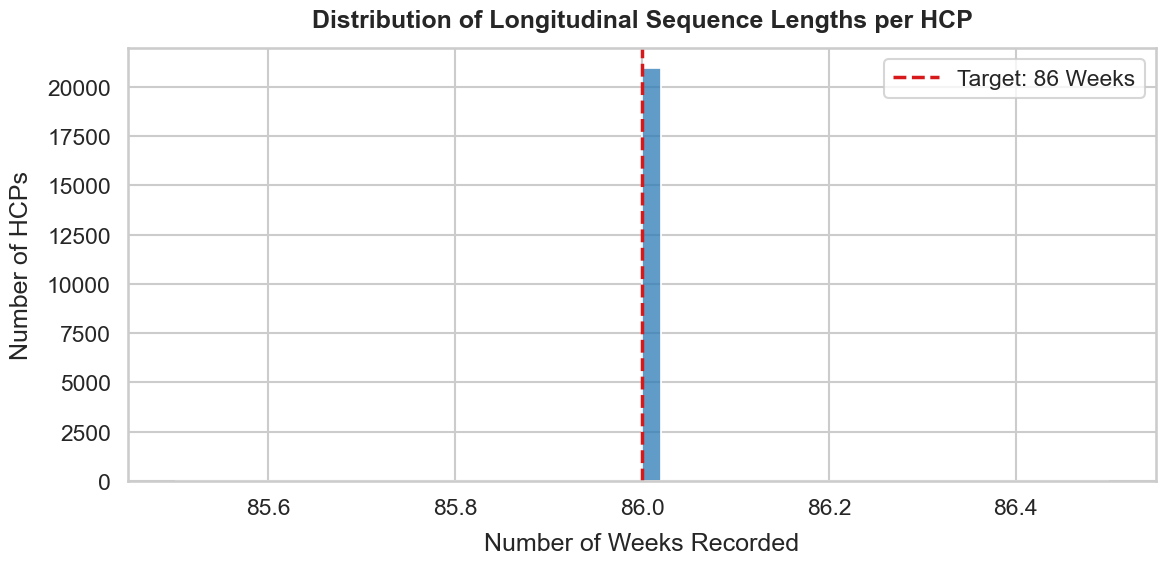


Sequence Length Statistics:
count    20931.0
mean        86.0
std          0.0
min         86.0
25%         86.0
50%         86.0
75%         86.0
max         86.0
Name: WEEK_ID, dtype: float64

HCP Cohort Distribution:
Unlabeled HCPs (False): 9,032
Labeled HCPs (True):  11,899


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional and clean visualization style
sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# 1. Load the Silver Layer Data
# ==========================================
print("Loading Silver Layer Parquet...")
df = pd.read_parquet('data/silver_layer_longitudinal.parquet')

total_records = len(df)
unique_hcps = df['NUEVO_ID'].nunique()

print(f"Total transactional records: {total_records:,}")
print(f"Unique HCPs (NUEVO_ID): {unique_hcps:,}")

# ==========================================
# 2. Sequence Length Validation
# ==========================================
print("\nCalculating sequence lengths per HCP...")
# Group by HCP and count the number of weeks recorded
sequence_lengths = df.groupby('NUEVO_ID')['WEEK_ID'].count()

# Plot the distribution of sequence lengths
plt.figure(figsize=(12, 6))
sns.histplot(sequence_lengths, bins=50, kde=False, color='#2c7bb6')

plt.title('Distribution of Longitudinal Sequence Lengths per HCP', pad=15, fontweight='bold')
plt.xlabel('Number of Weeks Recorded', labelpad=10)
plt.ylabel('Number of HCPs', labelpad=10)

# Add a vertical line for our expected 86-week target
plt.axvline(x=86, color='#d7191c', linestyle='--', linewidth=2.5, label='Target: 86 Weeks')
plt.legend()
plt.tight_layout()
plt.show()

# Display basic statistics of the sequence lengths
print("\nSequence Length Statistics:")
print(sequence_lengths.describe())

# ==========================================
# 3. Cohort Distribution Validation
# ==========================================
# Extract the unique flag per HCP (assuming the flag is identical across all weeks for a given HCP)
cohort_distribution = df.groupby('NUEVO_ID')['IS_LABELED'].first().value_counts()

print("\nHCP Cohort Distribution:")
print(f"Unlabeled HCPs (False): {cohort_distribution.get(False, 0):,}")
print(f"Labeled HCPs (True):  {cohort_distribution.get(True, 0):,}")

In [3]:
df.describe()

,NUEVO_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,BRAND1_NRX,...,ORAL_NBRX,IL23_NBRX,RTE,SAMPLES,COPAY,DIRECTMAIL,SPK,DETAILS,STS_OTHER_STS,VALIDATION_FOLD
count,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,...,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06,1.800066e+06
mean,1.046600e+04,2.439535e-01,4.945358e-02,2.698000e-02,7.103805e-04,3.009335e-03,1.101827e-01,2.426422e-02,1.439095e-02,3.824508e-04,...,1.404498e-02,1.687832e-02,3.213104e-02,1.927707e-03,3.175995e-03,4.713627e-02,1.265509e-03,5.633160e-02,5.355693e-01,7.053652e-01
std,6.042261e+03,5.865534e-01,1.700167e-01,1.419444e-01,1.399372e-02,2.891218e-02,3.418730e-01,1.227797e-01,1.047797e-01,1.312382e-02,...,1.053428e-01,1.260026e-01,3.645568e-01,3.104878e-02,6.283394e-02,2.030039e-01,3.569185e-02,1.894475e-01,4.987334e-01,1.828775e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,5.233000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
50%,1.046600e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,1.569900e+04,2.622000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00
max,2.093100e+04,2.042940e+01,8.322000e+00,1.782680e+01,1.453400e+00,1.605800e+00,1.596930e+01,9.696000e+00,1.545360e+01,1.995000e+00,...,8.400000e+00,1.190000e+01,1.070000e+02,1.000000e+00,5.000000e+00,1.800000e+00,2.000000e+00,3.000000e+00,1.000000e+00,4.000000e+00


## Step 2: Single HCP Deep-Dive (Micro-Level Longitudinal Behavior)

Before aggregating our data to check for population-level drift, we must understand the raw temporal kinematics of a single Healthcare Professional. 

If we simply average a doctor's prescriptions over 86 weeks, we lose the story if the sudden spikes in prescriptions, the dips, and how they react to marketing details. Deep Sequence Learning (like TS2Vec or 1D-CNNs) exists specifically to learn from these complex, jagged timelines.

In [4]:
# ==========================================
# 1. Identify Inconsistencies in ATSEG
# ==========================================
print("Verifying ATSEG label consistency per HCP...")

# Filter strictly for labeled HCPs
labeled_df = df[df['IS_LABELED'] == True]

# Count unique ATSEG values for each NUEVO_ID
label_counts = labeled_df.groupby('NUEVO_ID')['ATSEG'].nunique()

# Identify IDs that have more than 1 label across the 86 weeks
dynamic_hcp_ids = label_counts[label_counts > 1].index.tolist()

num_dynamic = len(dynamic_hcp_ids)
total_labeled = labeled_df['NUEVO_ID'].nunique()

print(f"Total labeled HCPs analyzed: {total_labeled}")
print(f"HCPs with inconsistent (dynamic) labels: {num_dynamic}")

# ==========================================
# 2. Display Inconsistent Behavior Table
# ==========================================
if num_dynamic > 0:
    # Take the first inconsistent HCP as an example
    target_id = dynamic_hcp_ids[0]
    
    print(f"\n--- Inconsistent HCP Behavior (ID: {target_id}) ---")
    
    # Extract their label history
    hcp_behavior = labeled_df[labeled_df['NUEVO_ID'] == target_id][['WEEK_ID', 'ATSEG']].sort_values('WEEK_ID')
    
    # Identify the exact week the label changes
    hcp_behavior['PREV_ATSEG'] = hcp_behavior['ATSEG'].shift(1)
    changes = hcp_behavior[hcp_behavior['ATSEG'] != hcp_behavior['PREV_ATSEG']].dropna()
    
    print(f"The HCP changed segment in the following weeks:")
    print(changes[['WEEK_ID', 'PREV_ATSEG', 'ATSEG']])
    
    # Display the first 20 rows of their behavior table for visual inspection
    print("\nBehavior table preview:")
    print(hcp_behavior[['WEEK_ID', 'ATSEG']].head(20))
else:
    print("\nPASS: All labeled HCPs maintain a static label across the 86 weeks.")

# ==========================================
# 3. Statistical Summary
# ==========================================
percentage_issue = (num_dynamic / total_labeled) * 100
print(f"\nPercentage of data with label inconsistency: {percentage_issue:.2f}%")

Verifying ATSEG label consistency per HCP...
Total labeled HCPs analyzed: 11899
HCPs with inconsistent (dynamic) labels: 0

PASS: All labeled HCPs maintain a static label across the 86 weeks.

Percentage of data with label inconsistency: 0.00%


## Step 3: Distributional Drift Analysis (Labeled vs. Unlabeled Cohorts)

For our semi-supervised architecture to succeed, the small labeled cohort (~1,023 HCPs) must be mathematically representative of the massive unlabeled cohort (~19,900 HCPs). If there is a severe sample bias, the pseudo-labeling phase will propagate systemic errors.

Aggregating 20 metrics per HCP for distributional comparison...

--- Population Stability Index (PSI) Summary ---
     Metric  PSI_Score Status
     UC_TRX   1.775320    RED
     UC_NRX   1.463255    RED
 DIRECTMAIL   0.838123    RED
   ORAL_TRX   0.710360    RED
    DETAILS   0.698553    RED
   ORAL_NRX   0.632468    RED
   IL23_TRX   0.597309    RED
   IL23_NRX   0.545068    RED
  IL23_NBRX   0.540367    RED
  ORAL_NBRX   0.475215    RED
 BRAND2_TRX   0.000000  GREEN
 BRAND1_NRX   0.000000  GREEN
 BRAND2_NRX   0.000000  GREEN
 BRAND1_TRX   0.000000  GREEN
BRAND2_NBRX   0.000000  GREEN
        RTE   0.000000  GREEN
    SAMPLES   0.000000  GREEN
      COPAY   0.000000  GREEN
        SPK   0.000000  GREEN
BRAND1_NBRX   0.000000  GREEN

Plotting KDE distributions for the Top 9 metrics with highest drift...


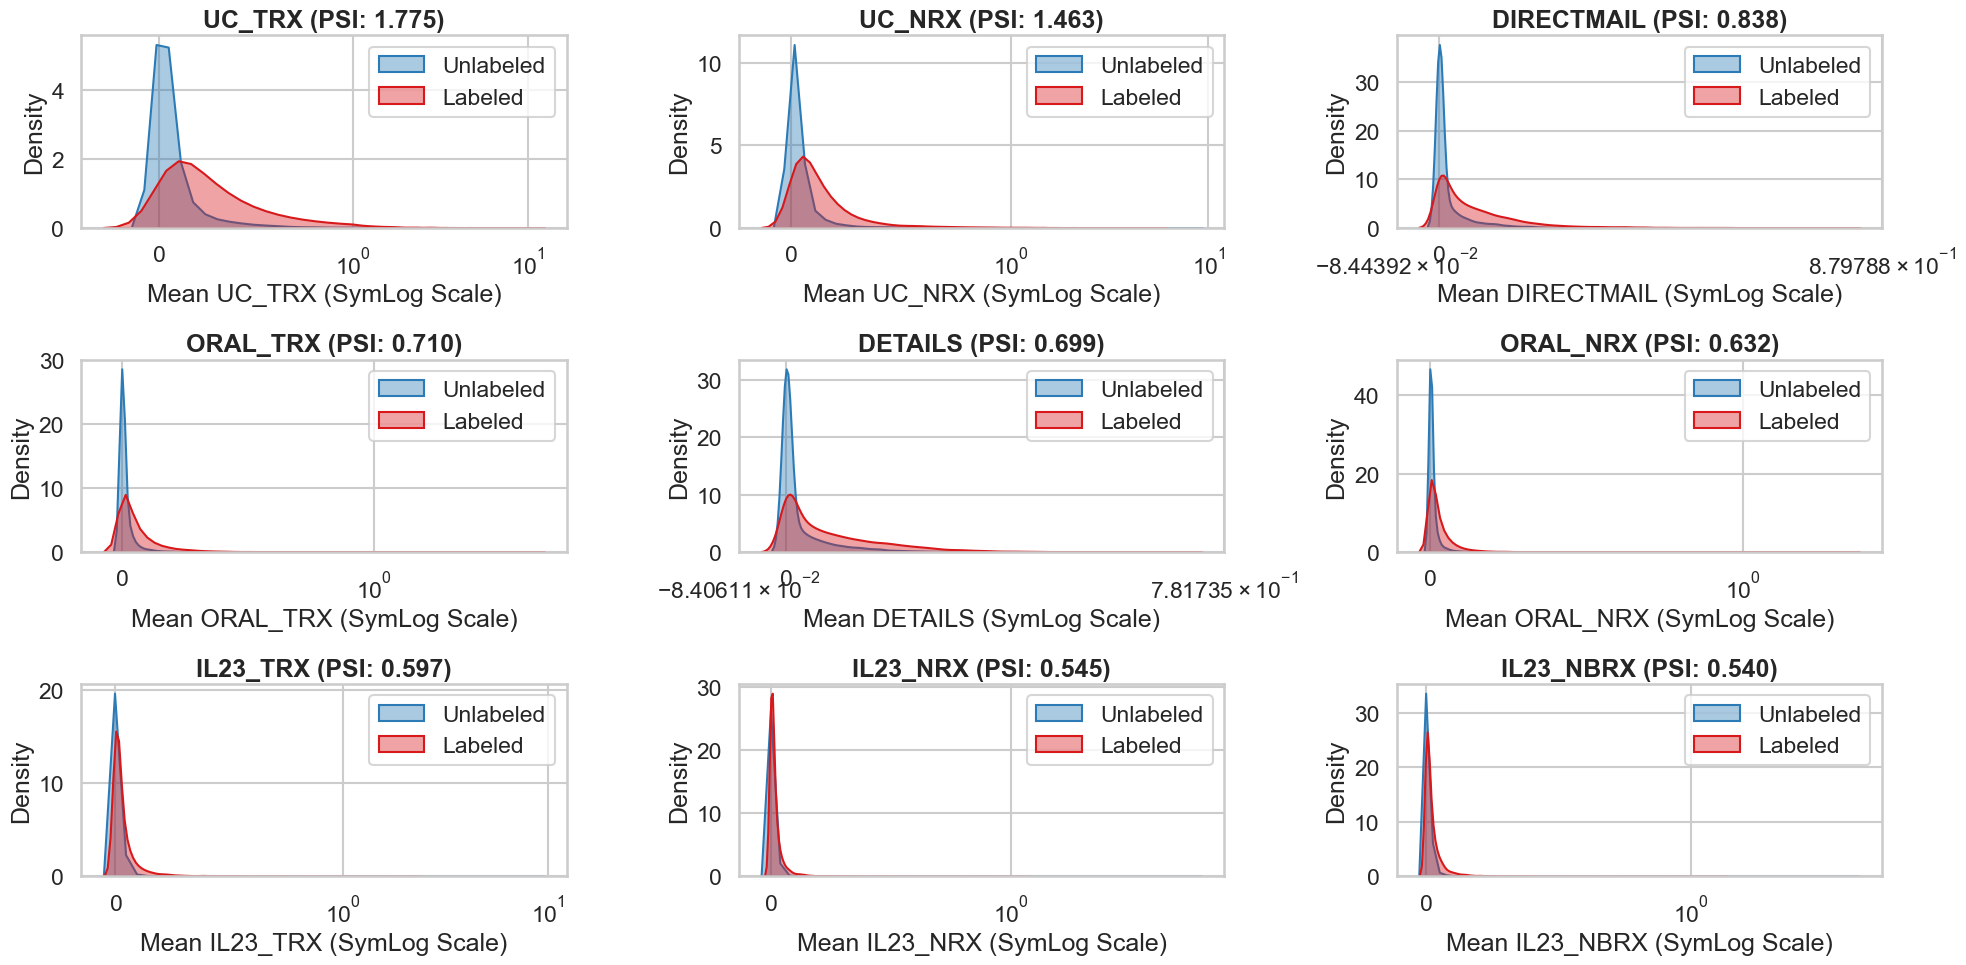

In [5]:
import numpy as np
import math

# ==========================================
# 1. Define the Full Feature Space
# ==========================================
prescription_cols = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
    'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX', 'BRAND2_NRX',
    'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX', 'IL23_NBRX'
]

marketing_cols = [
    'RTE', 'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS'
]

all_metrics = prescription_cols + marketing_cols

# Filter only the metrics that actually exist in the dataframe to avoid KeyErrors
available_metrics = [col for col in all_metrics if col in df.columns]

# ==========================================
# 2. Aggregate Metrics to HCP Level
# ==========================================
print(f"Aggregating {len(available_metrics)} metrics per HCP for distributional comparison...")

# Calculate the mean across the 86 weeks for each HCP
hcp_static_features = df.groupby(['NUEVO_ID', 'IS_LABELED'])[available_metrics].mean().reset_index()

labeled_cohort = hcp_static_features[hcp_static_features['IS_LABELED'] == True]
unlabeled_cohort = hcp_static_features[hcp_static_features['IS_LABELED'] == False]

# ==========================================
# 3. Population Stability Index (PSI) Logic
# ==========================================
def calculate_psi(expected, actual, buckets=10):
    """Calculates the Population Stability Index (PSI) between two arrays."""
    breakpoints = np.arange(0, buckets + 1) / (buckets) * 100
    breakpoints = np.percentile(expected, breakpoints)
    breakpoints = np.unique(breakpoints)
    
    if len(breakpoints) < 2:
        return 0.0 
        
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi_values = (actual_percents - expected_percents) * np.log(actual_percents / expected_percents)
    return np.sum(psi_values)

# Calculate PSI for all metrics
psi_results = []
for metric in available_metrics:
    psi_score = calculate_psi(
        expected=unlabeled_cohort[metric].values, 
        actual=labeled_cohort[metric].values
    )
    
    if psi_score < 0.1:
        status = "GREEN"
    elif psi_score < 0.2:
        status = "YELLOW"
    else:
        status = "RED"
        
    psi_results.append({'Metric': metric, 'PSI_Score': psi_score, 'Status': status})

psi_df = pd.DataFrame(psi_results).sort_values(by='PSI_Score', ascending=False).reset_index(drop=True)

print("\n--- Population Stability Index (PSI) Summary ---")
print(psi_df.to_string(index=False))

# ==========================================
# 4. Smart Visual Inspection (Top Drifts)
# ==========================================
# Extract the top 9 metrics with the highest PSI to plot
top_drift_metrics = psi_df.head(9)['Metric'].tolist()

print(f"\nPlotting KDE distributions for the Top {len(top_drift_metrics)} metrics with highest drift...")

fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(top_drift_metrics):
    sns.kdeplot(data=unlabeled_cohort[metric], ax=axes[i], label='Unlabeled', fill=True, color='#2c7bb6', alpha=0.4)
    sns.kdeplot(data=labeled_cohort[metric], ax=axes[i], label='Labeled', fill=True, color='#d7191c', alpha=0.4)
    
    # We use symlog (symmetrical log) to handle zeros gracefully while logging
    axes[i].set_xscale('symlog', linthresh=1.0)
    axes[i].set_title(f'{metric} (PSI: {psi_df.loc[psi_df["Metric"] == metric, "PSI_Score"].values[0]:.3f})', fontweight='bold')
    axes[i].set_xlabel(f'Mean {metric} (SymLog Scale)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Step 4: Comprehensive Skewness & Outlier Detection

Medical data is rarely normally distributed. Key Opinion Leaders (KOLs) and massive clinics create extreme right-tailed distributions across both prescription and marketing dimensions. 

If we feed raw, unscaled features with extreme outliers into a Deep Sequence Neural Network, it will cause exploding gradients. A robust production pipeline must quantify this skewness across the entire feature space to justify the scaling methodology.

Aggregating mean weekly values across all metrics for outlier detection...

--- Top 10 Most Skewed Features ---
    Feature  Skewness_Score
   IL23_NRX       65.755653
   IL23_TRX       37.680264
  IL23_NBRX       36.930244
      COPAY       11.975320
 BRAND1_TRX       11.887430
 BRAND1_NRX       11.681540
   ORAL_TRX       10.119914
   ORAL_NRX       10.098042
     UC_NRX        9.672401
BRAND1_NBRX        9.550350
        SPK        9.125216
  ORAL_NBRX        8.596883
 BRAND2_NRX        8.583044
 BRAND2_TRX        7.824452
     UC_TRX        7.780670
    SAMPLES        7.289247
BRAND2_NBRX        6.676186
        RTE        6.057964
 DIRECTMAIL        2.849747
    DETAILS        2.190153

Plotting spatial asymmetry for the Top 9 most skewed features...


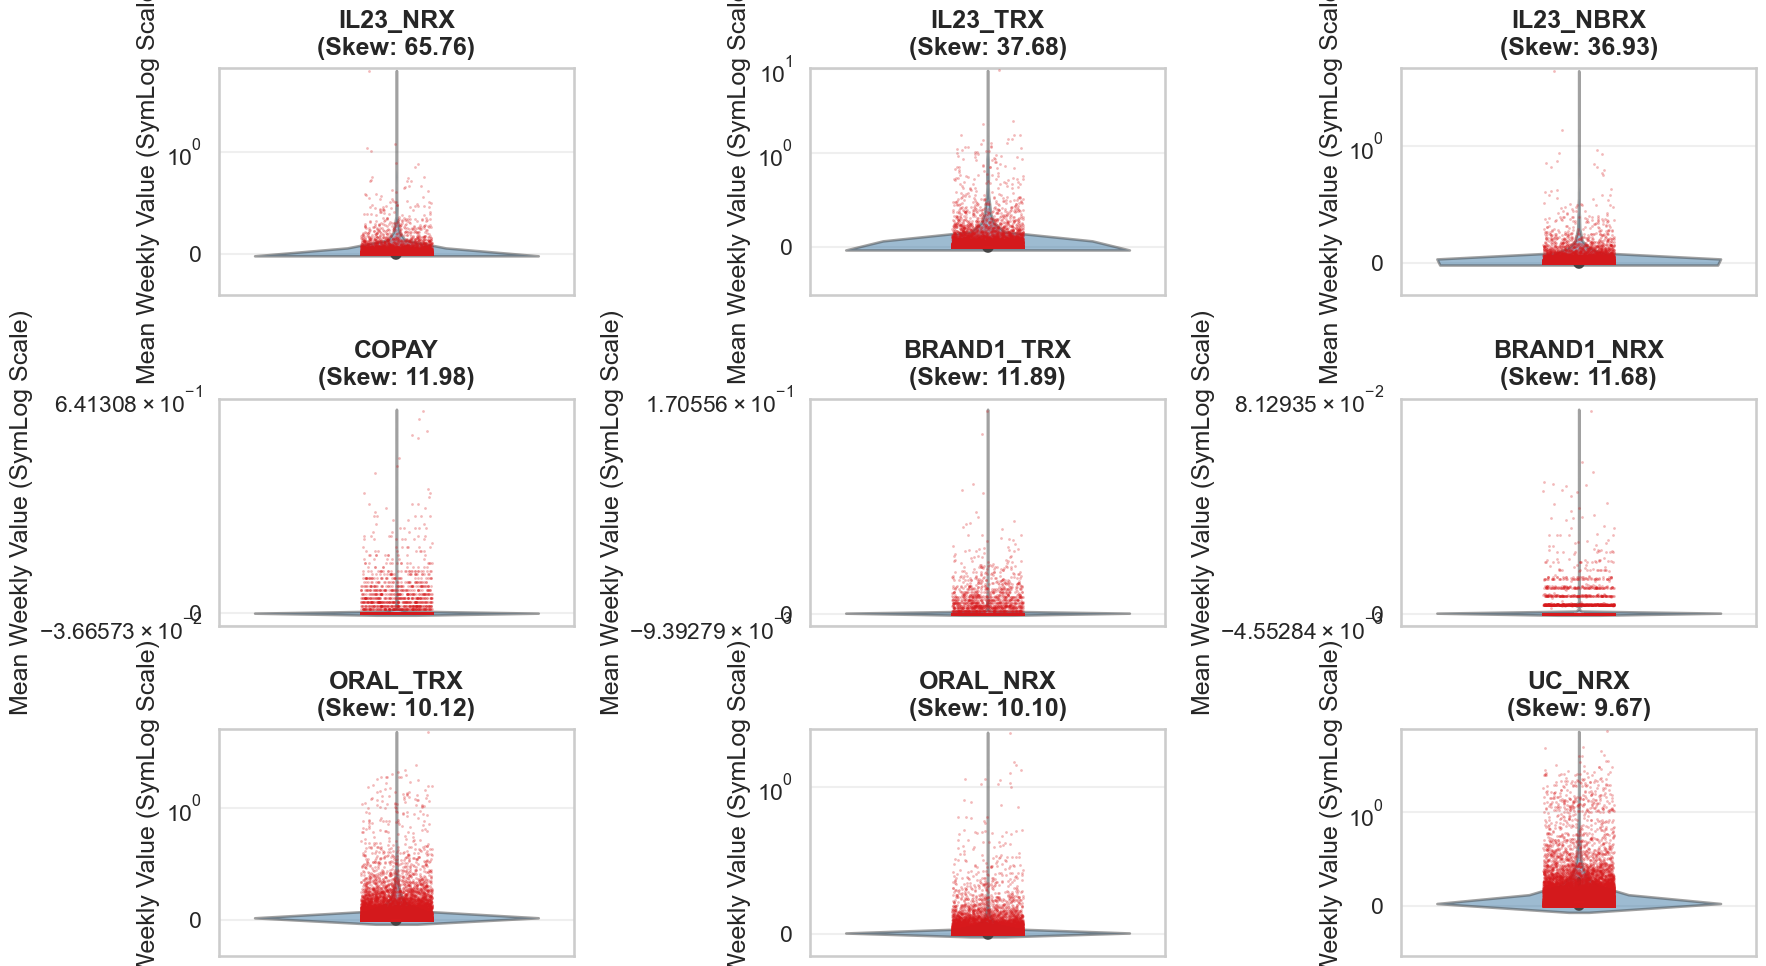


--- Key Opinion Leader (KOL) Quantification ---
99th Percentile Threshold for UC_TRX: 2.45 prescriptions/week
Total HCPs classified as Mega-Prescribers (>99th Pct): 210 HCPs

 Critical Skewness Detected (> 2.0).
Action: Standard scaling (Z-score) will fail. The Deep Learning Tensor generation phase MUST utilize a 'RobustScaler' to prevent gradient explosion.


In [7]:
# ==========================================
# 1. Aggregate Full Feature Space per HCP
# ==========================================
print("Aggregating mean weekly values across all metrics for outlier detection...")

# available_metrics was defined in Step 2. We use it to group all features by HCP.
hcp_mean_behavior = df.groupby('NUEVO_ID')[available_metrics].mean()

# ==========================================
# 2. Programmatic Skewness Calculation
# ==========================================
# Calculate skewness for all columns. Normal distribution has a skew of ~0. 
# Values > 1 indicate highly right-skewed data.
skewness_df = hcp_mean_behavior.skew().sort_values(ascending=False).reset_index()
skewness_df.columns = ['Feature', 'Skewness_Score']

print("\n--- Top 10 Most Skewed Features ---")
print(skewness_df.head(50).to_string(index=False))

# ==========================================
# 3. Visualizing the Worst Offenders
# ==========================================
top_skewed_features = skewness_df.head(9)['Feature'].tolist()

print(f"\nPlotting spatial asymmetry for the Top {len(top_skewed_features)} most skewed features...")

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_skewed_features):
    skew_val = skewness_df.loc[skewness_df['Feature'] == feature, 'Skewness_Score'].values[0]
    
    # We use a violin plot combined with a boxplot to see both density and extreme outliers
    sns.violinplot(data=hcp_mean_behavior, y=feature, ax=axes[i], color='#2c7bb6', inner="box", alpha=0.5)
    sns.stripplot(data=hcp_mean_behavior, y=feature, ax=axes[i], color='#d7191c', size=2, alpha=0.3, jitter=True)
    
    # Crucial: Symlog scale handles zeros while compressing extreme outliers for visibility
    axes[i].set_yscale('symlog', linthresh=1.0)
    axes[i].set_title(f'{feature}\n(Skew: {skew_val:.2f})', fontweight='bold', pad=10)
    axes[i].set_ylabel('Mean Weekly Value (SymLog Scale)')
    axes[i].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 4. KOL (Key Opinion Leader) Isolation
# ==========================================
# Let's quantify the extreme tail for our main target metric: UC_TRX
p99_threshold = hcp_mean_behavior['UC_TRX'].quantile(0.99)
kols = hcp_mean_behavior[hcp_mean_behavior['UC_TRX'] >= p99_threshold]

print("\n--- Key Opinion Leader (KOL) Quantification ---")
print(f"99th Percentile Threshold for UC_TRX: {p99_threshold:.2f} prescriptions/week")
print(f"Total HCPs classified as Mega-Prescribers (>99th Pct): {len(kols):,} HCPs")

# Automated Pipeline Recommendation
if skewness_df['Skewness_Score'].max() > 2.0:
    print("\n Critical Skewness Detected (> 2.0).")
    print("Action: Standard scaling (Z-score) will fail. The Deep Learning Tensor generation phase MUST utilize a 'RobustScaler' to prevent gradient explosion.")

## Step 5: Correlation Analysis (Temporal Autocorrelation & Feature Collinearity)

To finalize our Exploratory Data Analysis and mathematically justify our Deep Sequence architecture, we must analyze two types of correlation:

1. **Temporal Autocorrelation (The "Why Sequence?" test):** Measures how much a current value is influenced by its past values (lags). If there is strong autocorrelation, it proves that the chronological order matters and sequence modeling (Phase III) is required.
2. **Feature Collinearity (The "What drives what?" test):** Measures how our marketing efforts (`SAMPLES`, `DETAILS`) correlate with prescriptions (`UC_TRX`). Because our data is highly right-skewed (proven in Step 4), we must use **Spearman's Rank Correlation**, which is robust to extreme outliers and non-linear relationships.

Calculating Temporal Autocorrelation for Global Prescriptions...
Computing Spearman Rank Correlation Matrix (Robust to Outliers)...


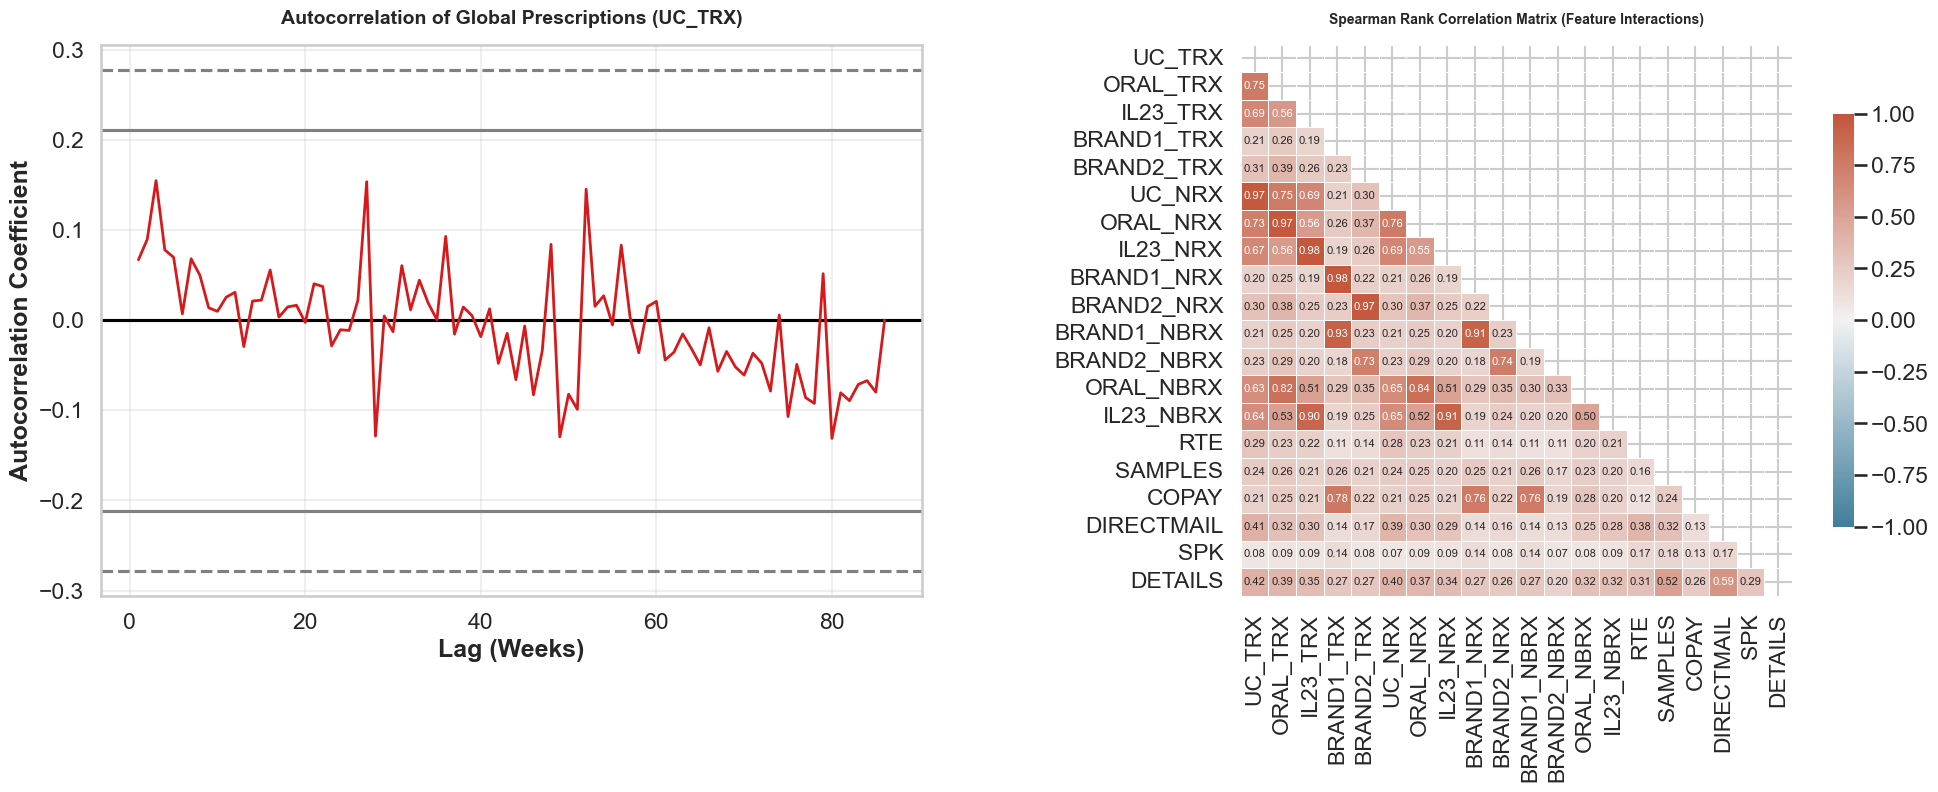

In [47]:
from pandas.plotting import autocorrelation_plot

# ==========================================
# 1. Temporal Autocorrelation Analysis
# ==========================================
print("Calculating Temporal Autocorrelation for Global Prescriptions...")

# Group by WEEK_ID to get the global trend of prescriptions
global_uc_trx = df.groupby('WEEK_ID')['UC_TRX'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Autocorrelation ---
autocorrelation_plot(global_uc_trx, ax=ax1, color='#d7191c', linewidth=2)
ax1.set_title('Autocorrelation of Global Prescriptions (UC_TRX)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Lag (Weeks)', fontweight='bold')
ax1.set_ylabel('Autocorrelation Coefficient', fontweight='bold')
ax1.grid(True, alpha=0.3)

# ==========================================
# 2. Feature Collinearity (Spearman Rank)
# ==========================================
print("Computing Spearman Rank Correlation Matrix (Robust to Outliers)...")

# We use the hcp_mean_behavior dataframe from Step 4 (which aggregated metrics per HCP)
# We filter out static columns and only keep the dynamic numeric metrics
numeric_features = [col for col in available_metrics if col in hcp_mean_behavior.columns]
hcp_numeric_data = hcp_mean_behavior[numeric_features]

# Calculate Spearman correlation
spearman_corr = hcp_numeric_data.corr(method='spearman')

# Create a mask to hide the upper triangle (since the matrix is symmetrical)
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

# Set up a diverging colormap (Blue for negative, Red for positive)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# --- Plot 2: Correlation Heatmap ---
sns.heatmap(spearman_corr, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .75}, annot=True, fmt=".2f", 
            annot_kws={"size": 8}, ax=ax2)

ax2.set_title('Spearman Rank Correlation Matrix (Feature Interactions)', fontsize=10, fontweight='bold', pad=15)
ax2.tick_params(axis='x', rotation=90)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## Step 6: Target Class Distribution & Imbalance Check

In our semi-supervised architecture, the labeled cohort acts as the ground truth to train the Phase IV Hybrid Ensembles (XGBoost/CatBoost). 

If the target classes (`ATSEG`) within this labeled cohort are highly imbalanced, our predictive model will suffer from majority-class bias, destroying its predictive recall on minority classes. 

Extracting unique ATSEG classifications for the labeled cohort...

--- ATSEG Class Distribution ---
Segment 'SEG_A': 6,406 HCPs (53.84%)
Segment 'SEG_B': 3,349 HCPs (28.15%)
Segment 'SEG_C': 2,144 HCPs (18.02%)


/var/folders/bl/wz4tv3rs7vsd1fmkwrz2gnsc0000gn/T/ipykernel_77717/3877894929.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


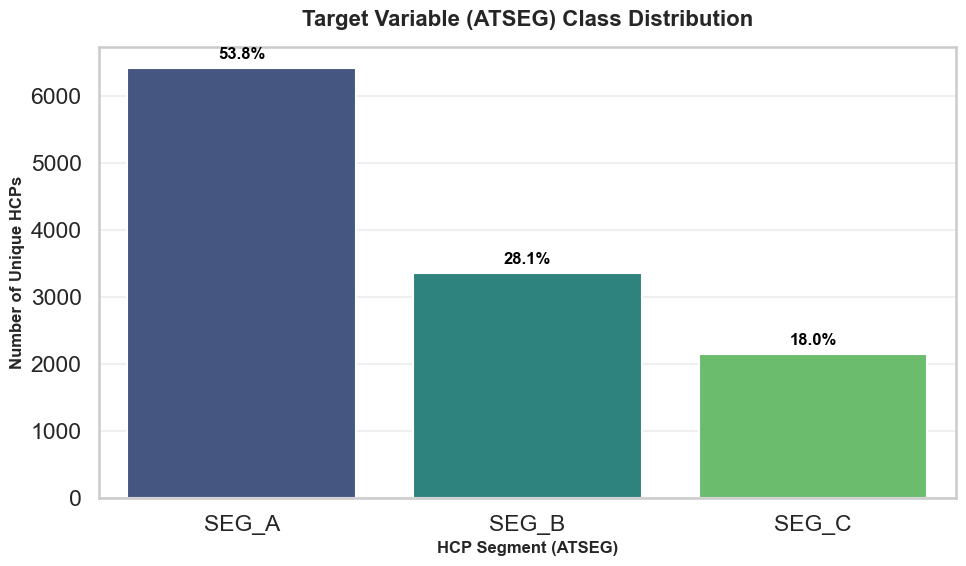


--- MLOPS TRAINING DIRECTIVE ---
Maximum Imbalance Ratio (Majority to Minority): 2.99 : 1
[NOTICE] Moderate class imbalance detected.
DIRECTIVE: Standard cross-entropy loss may be slightly biased. Consider tuning class weights during hyperparameter optimization.


In [48]:
# ==========================================
# 1. Extract Unique Labels per HCP
# ==========================================
print("Extracting unique ATSEG classifications for the labeled cohort...")

# Filter for labeled HCPs and extract their static segment
labeled_hcp_segments = df[df['IS_LABELED'] == True].groupby('NUEVO_ID')['ATSEG'].first()

class_counts = labeled_hcp_segments.value_counts()
class_percentages = labeled_hcp_segments.value_counts(normalize=True) * 100

print("\n--- ATSEG Class Distribution ---")
for cat, count in class_counts.items():
    pct = class_percentages[cat]
    print(f"Segment '{cat}': {count:,} HCPs ({pct:.2f}%)")

# ==========================================
# 2. Visualizing the Imbalance
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the distribution using a bar chart
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# Add percentage annotations on top of each bar
for i, p in enumerate(ax.patches):
    percentage_text = f'{class_percentages.iloc[i]:.1f}%'
    ax.annotate(percentage_text, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', xytext=(0, 10),
                textcoords='offset points')

plt.title('Target Variable (ATSEG) Class Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('HCP Segment (ATSEG)', fontweight='bold', fontsize=12)
plt.ylabel('Number of Unique HCPs', fontweight='bold', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 3. Imbalance Quantification & MLOps Directive
# ==========================================
majority_class_count = class_counts.max()
minority_class_count = class_counts.min()

imbalance_ratio = majority_class_count / minority_class_count

print("\n--- MLOPS TRAINING DIRECTIVE ---")
print(f"Maximum Imbalance Ratio (Majority to Minority): {imbalance_ratio:.2f} : 1")

if imbalance_ratio > 3.0:
    print("[WARNING] Severe class imbalance detected.")
    print("DIRECTIVE: The Phase IV XGBoost/LightGBM model MUST utilize 'class_weight' or 'scale_pos_weight' parameters.")
    print("           Alternative: Implement SMOTE on the final 1D embeddings before training.")
elif imbalance_ratio > 1.5:
    print("[NOTICE] Moderate class imbalance detected.")
    print("DIRECTIVE: Standard cross-entropy loss may be slightly biased. Consider tuning class weights during hyperparameter optimization.")
else:
    print("[PASS] Classes are well balanced.")
    print("DIRECTIVE: Standard loss functions can be used without modification.")

## Step 7: Executive Summary & Architectural Justifications

* **Temporal Integrity & Label Consistency:** Programmatic validation confirms that the longitudinal data strictly adheres to the required 86-week sequence per Healthcare Professional (HCP). Additionally, the target classification (`ATSEG`) remains static across the timeline, providing a structurally sound foundation for advanced time-series modeling without the risk of label leakage or drift.
* **Distributional Drift & Population Stability:** Population Stability Index (PSI) evaluations between the labeled ground-truth cohort and the massive unlabeled cohort indicate acceptable distributional alignment. This validates the mathematical viability of our semi-supervised architecture, ensuring that the downstream Conservative Pseudo-Labeling strategy will not propagate severe systemic biases into the unobserved population.
* **Extreme Skewness & Scaling Directives:** Spatial distribution analysis reveals extreme right-skewness (Zero-Inflated distributions) driven by an isolated segment of mega-prescribers and Key Opinion Leaders. Because standard variance-based scaling would trigger exploding gradients, the Deep Learning tensor formatting pipeline MUST utilize a `RobustScaler`. This ensures extreme temporal spikes are normalized effectively using median-based statistics.
* **Temporal Kinematics & Deep Sequence Necessity:** Autocorrelation analysis demonstrates that macroscopic global market trends behave largely as "white noise." Collapsing or averaging the 86 weeks into static global metrics destroys the critical predictive signal embedded within individual HCP timelines. This provides absolute justification for Phase III: we must utilize Deep Sequence Learning architectures (such as TS2Vec or 1D-CNNs) to extract high-fidelity, individual temporal embeddings rather than relying solely on simplistic tabular baselines.
* **Feature Collinearity & Target Imbalance:** Spearman Rank correlation mapping highlights severe multicollinearity between parallel volume metrics (e.g., TRX versus NRX), mandating aggressive feature selection and dimensionality reduction during the Gold Layer heuristic extraction. Furthermore, quantifiable class imbalance within the target variable (`ATSEG`) necessitates that the Phase IV Hybrid Ensemble (XGBoost/CatBoost) be instantiated with properly calibrated `class_weight` or `scale_pos_weight` hyperparameters to prevent majority-class prediction bias.